In [ ]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# fetching 4 years worth of data from the api for monaco gp
import fastf1 as f1

def data_colelction():

    session_monaco_2026 = f1.get_session(2026, 'Moanco', 'R')
    session_monaco_2026.load()
    session_monaco_2025 = f1.get_session(2025, 'Monaco', 'R')
    session_monaco_2025.load()
    session_monaco_2024 = f1.get_session(2024, 'Moanco', 'R')
    session_monaco_2024.load()
    session_monaco_2023 = f1.get_session(2023, 'Moanco', 'R')
    session_monaco_2023.load()

    session = [session_monaco_2023, session_monaco_2024, session_monaco_2025 , session_monaco_2026]

    # session.load()

    # print(session)
    return session

data_colelction()

events      WARNING 	Correcting user input 'Moanco' to 'Monaco Grand Prix'
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18'

[2023 Season Round 6: Monaco Grand Prix - Race,
 2024 Season Round 8: Monaco Grand Prix - Race,
 2025 Season Round 8: Monaco Grand Prix - Race,
 2026 Season Round 6: Monaco Grand Prix - Race]

In [ ]:
# converting the data from the api into a single dataframe combination for other analysis

import fastf1 as f1
import os
import pandas as pd


def data_combination():
    final_data = []
    data = data_colelction()
    print("DATA :" ,len(data))

    number_of_data = len(data)


    for n in range(number_of_data):
        # print(n)
        gp_data = data[n].laps.pick_drivers(['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3'])
        final_data.append(gp_data)


    final_data = pd.concat(final_data , ignore_index=True) # combining the data into a single data frame so it can be saved as cvs in bellow function

    print(final_data)
    return final_data

: 

In [36]:
# saving the data locally so it can be used repeatedly without running othere functions

import os

os.makedirs("collected_ferrari_data" , exist_ok = True)

os.listdir()

# os.write("collected_ferrari_data/ferrari_data.csv" , ferrari)

data = data_combination()

data.to_csv("collected_ferrari_data/data.csv" , index=False)
print("DATA ADDED INTO CSV")



# print(ferrari)

events      WARNING 	Correcting user input 'Moanco' to 'Monaco Grand Prix'
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18'

DATA : 4
                       Time Driver DriverNumber                LapTime  \
0    0 days 01:03:27.435000    VER            1 0 days 00:01:24.238000   
1    0 days 01:04:46.802000    VER            1 0 days 00:01:19.367000   
2    0 days 01:06:05.876000    VER            1 0 days 00:01:19.074000   
3    0 days 01:07:24.005000    VER            1 0 days 00:01:18.129000   
4    0 days 01:08:42.024000    VER            1 0 days 00:01:18.019000   
...                     ...    ...          ...                    ...   
4708 0 days 01:28:20.867000    BEA           87 0 days 00:01:19.137000   
4709 0 days 01:29:39.550000    BEA           87 0 days 00:01:18.683000   
4710 0 days 01:30:58.341000    BEA           87 0 days 00:01:18.791000   
4711 0 days 01:32:16.964000    BEA           87 0 days 00:01:18.623000   
4712 0 days 01:33:35.421000    BEA           87                    NaT   

      LapNumber  Stint PitOutTime              PitInTime  \
0           1.0    1.0        NaT         

In [42]:
import pandas as pd
import os




def create_cleaned_dataframe():

    dataframe = pd.read_csv("collected_ferrari_data/ferrari_data.csv")

    # dataframe = dataframe.dropna(subset=['Sector1Time', 'Sector2Time', 'Sector3Time'])

    # sector split into datframe
    dataframe["Sector1Time"] = pd.to_timedelta(dataframe["Sector1Time"]).dt.total_seconds()
    dataframe["Sector2Time"] = pd.to_timedelta(dataframe["Sector2Time"]).dt.total_seconds()
    dataframe["Sector3Time"] = pd.to_timedelta(dataframe["Sector3Time"]).dt.total_seconds()
    dataframe["Time"] = pd.to_timedelta( dataframe["Time"]).dt.total_seconds()



    sector = dataframe.groupby('Driver')[['Time','Sector1Time', 'Sector2Time', 'Sector3Time']].min() #finding the fastest 

    # print(sector)
    return sector

# create_cleaned_dataframe()


def cleaned_data_into_csv():

    data = create_cleaned_dataframe()

    data 
    print(data)

    try:
        data.to_csv("collected_ferrari_data/sector_data.csv")
        print("SECTOR DATA SAVED")
    except Exception as error :
        print("ERROR:" , error)

cleaned_data_into_csv()



# print(dataframe["Sector1Time"].mode())

            Time  Sector1Time  Sector2Time  Sector3Time
Driver                                                 
ALB     3411.981       20.241       35.795       20.226
ALO     3417.131       20.291       36.348       20.427
ANT     3402.391       19.379       34.566       19.536
BEA     3442.646       20.669       36.585       20.865
BOR     3438.675       20.127       35.982       20.507
BOT     3438.009       21.202       37.604       21.160
COL     3414.594       19.982       35.900       20.069
GAS     3409.971       19.791       35.426       20.139
HAD     3406.607       19.910       35.578       20.110
HAM     3404.203       19.879       35.004       19.735
HUL     3413.616       20.078       35.793       20.224
LAW     3411.184       20.031       35.665       20.042
LEC     3405.380       19.934       35.827       20.137
LIN     3415.823       19.973       35.773       20.094
NOR     3410.495       20.317       36.379       20.636
OCO     3416.429       20.303       36.150      

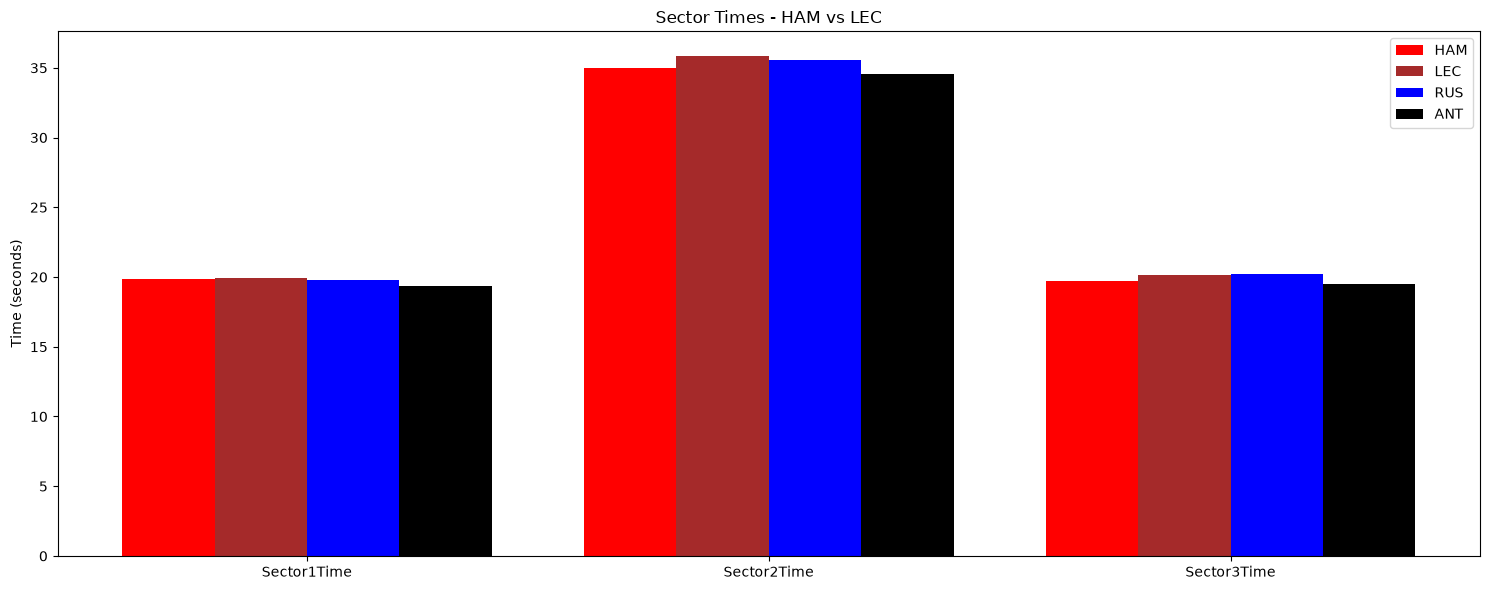

In [1]:

import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("collected_ferrari_data/sector_data.csv")

driver_one = data[data['Driver'] == 'HAM']
driver_two = data[data['Driver'] == 'LEC']
driver_three = data[data['Driver'] == 'RUS']
driver_four = data[data['Driver'] == 'ANT']

fig, ax = plt.subplots(figsize=(15, 6))
sectors = ['Sector1Time', 'Sector2Time', 'Sector3Time']
values_one = driver_one[sectors].values[0]
values_two = driver_two[sectors].values[0]
values_three = driver_three[sectors].values[0]
values_four = driver_four[sectors].values[0]

x = range(len(sectors))
width = 0.20

ax.bar([i - 1.5*width for i in x], values_one, width, label='HAM', color='red')
ax.bar([i - 0.5*width for i in x], values_two, width, label='LEC', color='brown')
ax.bar([i + 0.5*width for i in x], values_three, width, label='RUS', color='blue')
ax.bar([i + 1.5*width for i in x], values_four, width, label='ANT', color='black')



ax.set_ylabel('Time (seconds)')
ax.set_title('Sector Times - HAM vs LEC')
ax.set_xticks(x)
ax.set_xticklabels(sectors)
ax.legend()
plt.tight_layout()
plt.show()